# Trader Performance vs Market Sentiment (Hyperliquid)

Assignment for Primetrade.ai Data Science Intern role.

Using the Hyperliquid trade log (~211k trades, 32 accounts) and the Bitcoin
Fear/Greed index to see if trader behavior and performance change with market
sentiment.

Note: there's no leverage or account equity column in the trade data, so
wherever the brief asks about leverage I used trade size (USD) instead and
say so.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

## Part A - loading and cleaning

In [2]:
trades = pd.read_csv('data/historical_data__1_.csv')
fg = pd.read_csv('data/fear_greed_index__1_.csv')

print(trades.shape, fg.shape)

(211224, 16) (2644, 4)


In [3]:
# check for missing values / dupes on both files
print(trades.isnull().sum().sum(), 'missing values in trades')
print(trades.duplicated().sum(), 'duplicate rows in trades')
print(fg.isnull().sum().sum(), 'missing values in fg')
print(fg.duplicated().sum(), 'duplicate rows in fg')

0 missing values in trades


0 duplicate rows in trades
0 missing values in fg
0 duplicate rows in fg


Both files are clean, no nulls or dupes. Trades has 211,224 rows across 32
accounts. FG index covers 2018-2025, trades only 2023-2025, so I'll trim FG
to the overlapping window when merging.

In [4]:
# parse dates - use Timestamp IST not the raw Timestamp column (that one is
# ms epoch but the precision looks off when I checked it against IST, dates
# don't line up for most rows)
trades['date'] = pd.to_datetime(trades['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.normalize()
fg['date'] = pd.to_datetime(fg['date'])

# collapse extreme fear/fear and greed/extreme greed into 3 buckets, easier to read
def bucket(c):
    if c in ('Fear', 'Extreme Fear'):
        return 'Fear'
    if c in ('Greed', 'Extreme Greed'):
        return 'Greed'
    return 'Neutral'

fg['sentiment'] = fg['classification'].apply(bucket)

trades = trades.merge(fg[['date', 'classification', 'sentiment', 'value']], on='date', how='left')
print(trades['sentiment'].isnull().sum(), 'trades with no matching sentiment day, dropping these')
trades = trades.dropna(subset=['sentiment']).copy()

6 trades with no matching sentiment day, dropping these


## Key metrics

Building an account x day table since that's the level most of the
questions in the brief are asked at (daily pnl, win rate, trades/day etc).

Win rate is tricky here - about half the rows have Closed PnL = 0 because
they're position-opening trades, not closes. Counting those as losses would
tank every account's win rate for no reason, so I only count it over rows
where PnL actually got realized (non-zero).

In [5]:
trades['is_long_open'] = trades['Direction'] == 'Open Long'
trades['is_short_open'] = trades['Direction'] == 'Open Short'
trades['is_realized'] = trades['Closed PnL'] != 0

daily = trades.groupby(['Account', 'date']).agg(
    daily_pnl=('Closed PnL', 'sum'),
    n_trades=('Closed PnL', 'count'),
    n_realized=('is_realized', 'sum'),
    n_wins=('Closed PnL', lambda x: (x > 0).sum()),
    avg_trade_size_usd=('Size USD', 'mean'),
    total_volume_usd=('Size USD', 'sum'),
    n_long_open=('is_long_open', 'sum'),
    n_short_open=('is_short_open', 'sum'),
    sentiment=('sentiment', 'first'),
    fg_value=('value', 'first'),
).reset_index()

daily['win_rate'] = np.where(daily['n_realized'] > 0, daily['n_wins'] / daily['n_realized'], np.nan)
daily['long_short_ratio'] = np.where(daily['n_short_open'] > 0, daily['n_long_open'] / daily['n_short_open'], np.nan)
daily['net_long_bias'] = daily['n_long_open'] - daily['n_short_open']

print(daily.shape)
daily.head()

(2340, 15)


,Account,date,daily_pnl,n_trades,n_realized,n_wins,avg_trade_size_usd,total_volume_usd,n_long_open,n_short_open,sentiment,fg_value,win_rate,long_short_ratio,net_long_bias
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,177,0,0,5089.718249,900880.13,0,177,Greed,76.0,NaN,0.0,-177
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,68,0,0,7976.664412,542413.18,0,68,Greed,90.0,NaN,0.0,-68
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,40,0,0,23734.500000,949380.00,0,40,Greed,83.0,NaN,0.0,-40
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,12,12,0,28186.666667,338240.00,0,0,Greed,94.0,0.0,NaN,0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,27,12,12,17248.148148,465700.00,0,15,Greed,79.0,1.0,0.0,-15


## Part B - does performance differ between Fear and Greed days?

In [6]:
order = ['Fear', 'Neutral', 'Greed']
colors = ['#c0392b', '#7f8c8d', '#27ae60']

sent_perf = daily.groupby('sentiment').agg(
    n_account_days=('daily_pnl', 'count'),
    mean_daily_pnl=('daily_pnl', 'mean'),
    median_daily_pnl=('daily_pnl', 'median'),
    mean_win_rate=('win_rate', 'mean'),
    pct_profitable_days=('daily_pnl', lambda x: (x > 0).mean()),
).reindex(order)
sent_perf

,n_account_days,mean_daily_pnl,median_daily_pnl,mean_win_rate,pct_profitable_days
sentiment,,,,,
Fear,790,5185.146443,122.737038,0.842294,0.603797
Neutral,376,3438.618818,167.551743,0.835721,0.622340
Greed,1174,4144.208334,265.247725,0.856307,0.643101


In [7]:
# drawdown proxy - running peak minus current cumulative pnl, per account
daily_sorted = daily.sort_values(['Account', 'date']).copy()
daily_sorted['cum_pnl'] = daily_sorted.groupby('Account')['daily_pnl'].cumsum()
daily_sorted['drawdown'] = daily_sorted['cum_pnl'] - daily_sorted.groupby('Account')['cum_pnl'].cummax()
print(daily_sorted.groupby('sentiment')['drawdown'].mean().reindex(order))

sentiment
Fear      -8863.193211
Neutral   -9431.377301
Greed     -8892.618794
Name: drawdown, dtype: float64


In [8]:
# quick check on whether the fear/greed pnl gap is actually significant
# (pnl is heavily skewed so using mann-whitney instead of a t-test)
fear_pnl = daily.loc[daily['sentiment'] == 'Fear', 'daily_pnl'].dropna()
greed_pnl = daily.loc[daily['sentiment'] == 'Greed', 'daily_pnl'].dropna()
u, p = stats.mannwhitneyu(fear_pnl, greed_pnl, alternative='two-sided')
print(f'p = {p:.3f}')

p = 0.062


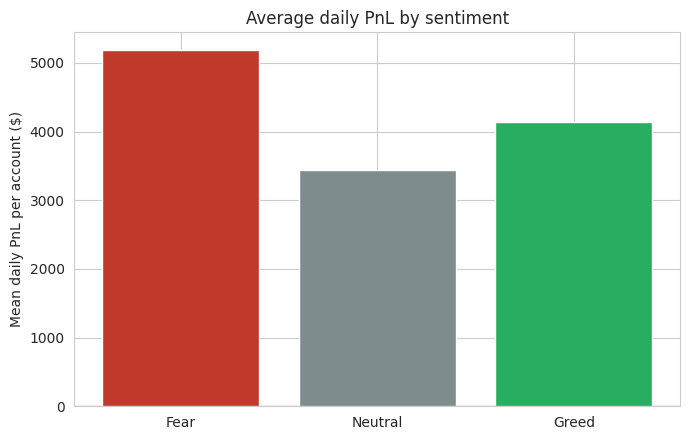

In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
vals = sent_perf.loc[order, 'mean_daily_pnl']
ax.bar(order, vals, color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Mean daily PnL per account ($)')
ax.set_title('Average daily PnL by sentiment')
plt.tight_layout()
plt.show()

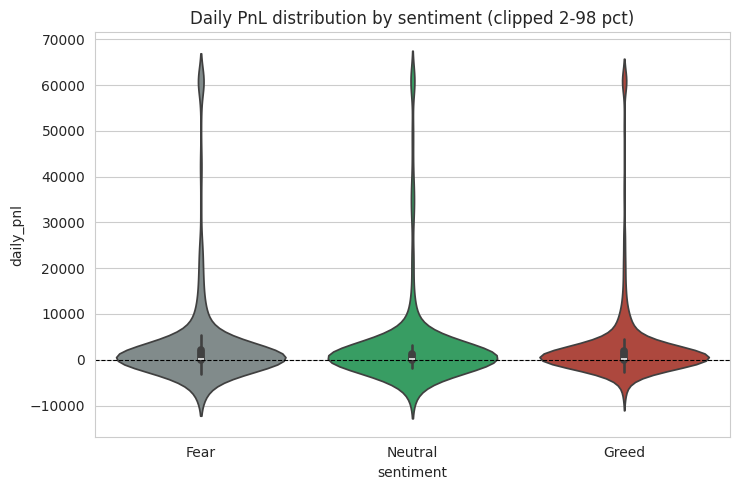

In [10]:
fig, ax = plt.subplots(figsize=(7.5, 5))
clipped = daily.copy()
lo, hi = clipped['daily_pnl'].quantile([0.02, 0.98])
clipped['daily_pnl'] = clipped['daily_pnl'].clip(lo, hi)
sns.violinplot(data=clipped, x='sentiment', y='daily_pnl', order=order, hue='sentiment',
               palette=colors, legend=False, ax=ax)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Daily PnL distribution by sentiment (clipped 2-98 pct)')
plt.tight_layout()
plt.show()

The mean daily PnL looks higher on Fear days but that's a few big winning
trades pulling the average up - PnL is very skewed. Median PnL and percent
of profitable days are both actually a bit higher on Greed days (median
~$265 vs ~$123, 64% vs 60% profitable days). The p-value on the fear vs
greed gap comes out around 0.06, so it's not a strong result either way.

## Do traders behave differently depending on sentiment?

In [11]:
behavior = daily.groupby('sentiment').agg(
    mean_trades_per_day=('n_trades', 'mean'),
    mean_trade_size_usd=('avg_trade_size_usd', 'mean'),
    mean_volume_usd=('total_volume_usd', 'mean'),
    mean_long_short_ratio=('long_short_ratio', 'mean'),
).reindex(order)
behavior

,mean_trades_per_day,mean_trade_size_usd,mean_volume_usd,mean_long_short_ratio
sentiment,,,,
Fear,105.363291,8529.859802,756720.318013,2.222829
Neutral,100.228723,6963.694861,479367.189043,1.357632
Greed,76.912266,5954.632633,351829.352036,1.300493


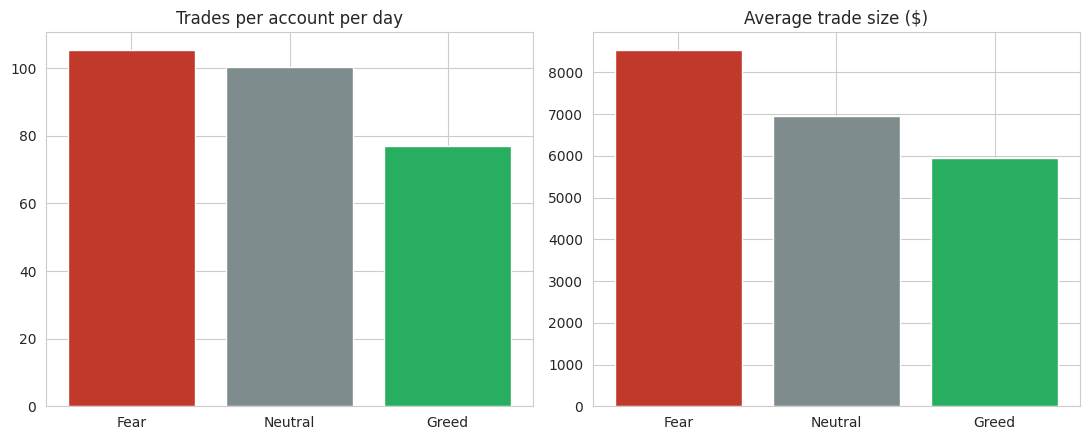

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(order, behavior['mean_trades_per_day'], color=colors)
axes[0].set_title('Trades per account per day')
axes[1].bar(order, behavior['mean_trade_size_usd'], color=colors)
axes[1].set_title('Average trade size ($)')
plt.tight_layout()
plt.show()

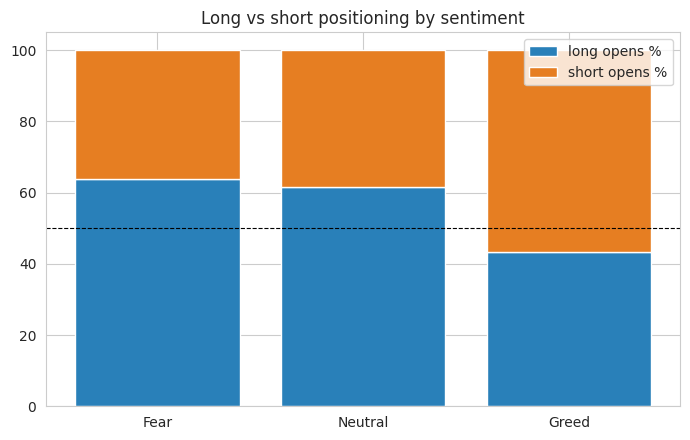

In [13]:
fig, ax = plt.subplots(figsize=(7, 4.5))
long_pct = daily.groupby('sentiment').apply(
    lambda d: d['n_long_open'].sum() / (d['n_long_open'].sum() + d['n_short_open'].sum()) * 100
).reindex(order)
ax.bar(order, long_pct, label='long opens %', color='#2980b9')
ax.bar(order, 100 - long_pct, bottom=long_pct, label='short opens %', color='#e67e22')
ax.axhline(50, color='black', linestyle='--', linewidth=0.8)
ax.set_title('Long vs short positioning by sentiment')
ax.legend()
plt.tight_layout()
plt.show()

Traders are clearly more active during Fear - about 105 trades/day vs 77 on
Greed days, bigger average trade size too ($8.5k vs $6k), roughly double
the daily volume. Long/short ratio is also higher during Fear (2.2 vs 1.3),
so people lean into buying the dip rather than pulling back.

## Trader segments

Splitting accounts into terciles on trade size and frequency, plus a
median split on percent-profitable-days for "consistent" vs not. No
leverage field in the data so trade size is standing in as an intensity
proxy here.

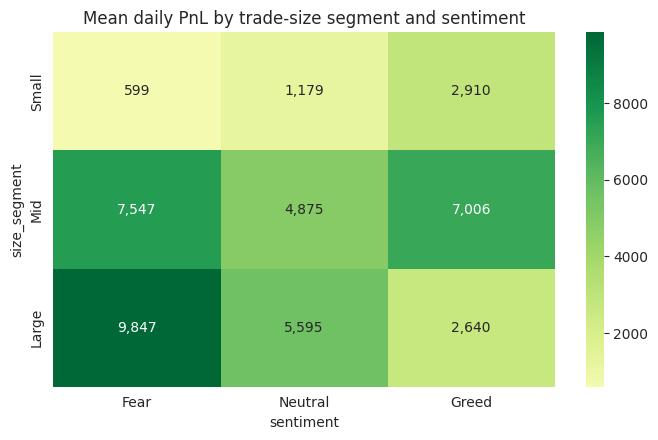

In [14]:
acct = daily.groupby('Account').agg(
    total_pnl=('daily_pnl', 'sum'),
    active_days=('date', 'nunique'),
    total_trades=('n_trades', 'sum'),
    avg_trade_size=('avg_trade_size_usd', 'mean'),
    total_volume=('total_volume_usd', 'mean'),
    pct_profitable_days=('daily_pnl', lambda x: (x > 0).mean()),
).reset_index()
acct['trades_per_active_day'] = acct['total_trades'] / acct['active_days']

size_q = acct['avg_trade_size'].quantile([1/3, 2/3]).values
acct['size_segment'] = acct['avg_trade_size'].apply(
    lambda x: 'Small' if x <= size_q[0] else ('Mid' if x <= size_q[1] else 'Large'))

acct['consistency_segment'] = np.where(
    acct['pct_profitable_days'] >= acct['pct_profitable_days'].median(), 'Consistent', 'Inconsistent')

daily_seg = daily.merge(acct[['Account', 'size_segment', 'consistency_segment']], on='Account', how='left')

seg1 = daily_seg.groupby(['size_segment', 'sentiment'])['daily_pnl'].mean().unstack().reindex(['Small', 'Mid', 'Large'])[order]
seg3 = daily_seg.groupby(['consistency_segment', 'sentiment'])['daily_pnl'].mean().unstack()[order]

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.heatmap(seg1, annot=True, fmt=',.0f', cmap='RdYlGn', center=0, ax=ax)
ax.set_title('Mean daily PnL by trade-size segment and sentiment')
plt.tight_layout()
plt.show()

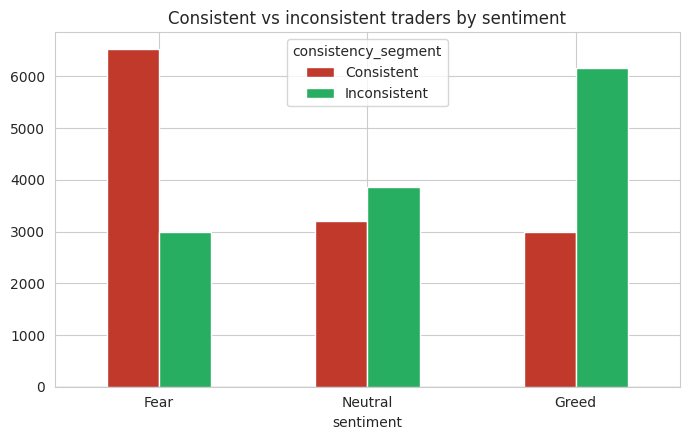

In [15]:
fig, ax = plt.subplots(figsize=(7, 4.5))
seg3.T.plot(kind='bar', ax=ax, color=['#c0392b', '#27ae60'])
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Consistent vs inconsistent traders by sentiment')
ax.set_xticklabels(order, rotation=0)
plt.tight_layout()
plt.show()

This is the more interesting split. Large-size and consistently profitable
accounts do noticeably better on Fear days (large size ~$9.8k vs ~$2.6k on
Greed, consistent traders ~$6.5k vs ~$3k). Inconsistent traders flip the
other way - their best days are during Greed (~$6.2k vs ~$3k on Fear).
Reads like the bigger/steadier traders are picking up fear-driven
mispricing while less consistent traders are catching momentum in hype
periods, which is a more fragile source of returns.

## Bonus - clustering traders into archetypes

In [16]:
feat_cols = ['avg_trade_size', 'trades_per_active_day', 'pct_profitable_days', 'total_volume']
X = StandardScaler().fit_transform(acct[feat_cols].fillna(acct[feat_cols].median()))
acct['cluster'] = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X)

profile = acct.groupby('cluster')[feat_cols].mean()
whale = profile['avg_trade_size'].idxmax()
scalper = profile['trades_per_active_day'].idxmax()
labels = {c: ('Whale' if c == whale and c != scalper else 'Scalper' if c == scalper else 'Retail')
          for c in profile.index}
acct['archetype'] = acct['cluster'].map(labels)
print(acct['archetype'].value_counts())

archetype
Retail     19
Scalper     9
Whale       4
Name: count, dtype: int64


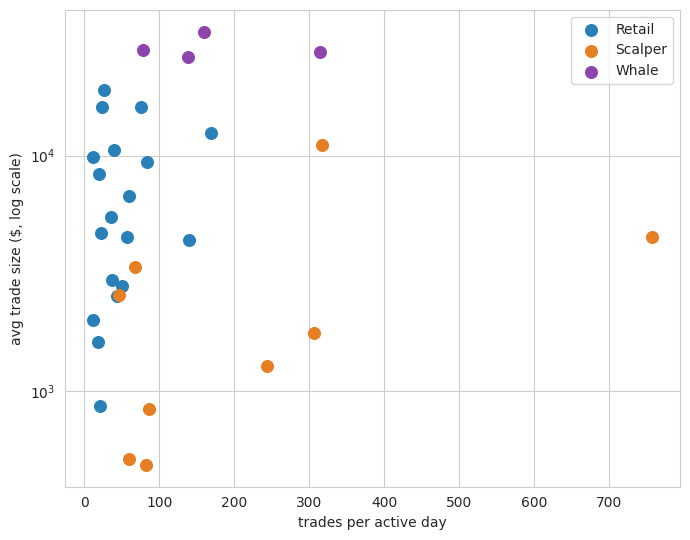

In [17]:
fig, ax = plt.subplots(figsize=(7, 5.5))
colors_map = {'Whale': '#8e44ad', 'Scalper': '#e67e22', 'Retail': '#2980b9'}
for a, sub in acct.groupby('archetype'):
    ax.scatter(sub['trades_per_active_day'], sub['avg_trade_size'], s=70, label=a, color=colors_map[a])
ax.set_yscale('log')
ax.set_xlabel('trades per active day')
ax.set_ylabel('avg trade size ($, log scale)')
ax.legend()
plt.tight_layout()
plt.show()

3 groups fall out pretty naturally: a small whale/position-trader group
(5 accounts, large trades, low frequency), a scalper group (9 accounts,
tiny trades, very high frequency), and the rest (18 accounts, more
average/retail-looking behavior).

## Bonus - simple next-day profitability model

Trying to predict whether an account will be profitable the next day using
today's sentiment + today's behavior. Random forest, class-weighted since
profitable days are the majority class (~77%).

In [18]:
model_df = daily_seg.sort_values(['Account', 'date']).copy()
model_df['next_day_profitable'] = (model_df.groupby('Account')['daily_pnl'].shift(-1) > 0).astype(int)

features = ['n_trades', 'avg_trade_size_usd', 'win_rate', 'long_short_ratio', 'net_long_bias', 'fg_value', 'daily_pnl']
model_data = model_df.dropna(subset=features + ['next_day_profitable'])

Xtr, Xte, ytr, yte = train_test_split(model_data[features], model_data['next_day_profitable'],
                                       test_size=0.25, random_state=42, stratify=model_data['next_day_profitable'])
clf = RandomForestClassifier(n_estimators=200, max_depth=5, random_state=42, class_weight='balanced')
clf.fit(Xtr, ytr)
pred = clf.predict(Xte)

print('accuracy:', accuracy_score(yte, pred))
print('baseline (always predict profitable):', ytr.mean())
print(classification_report(yte, pred))

accuracy: 0.677570093457944
baseline (always predict profitable): 0.76875
              precision    recall  f1-score   support

           0       0.36      0.48      0.41        50
           1       0.82      0.74      0.78       164

    accuracy                           0.68       214
   macro avg       0.59      0.61      0.59       214
weighted avg       0.71      0.68      0.69       214



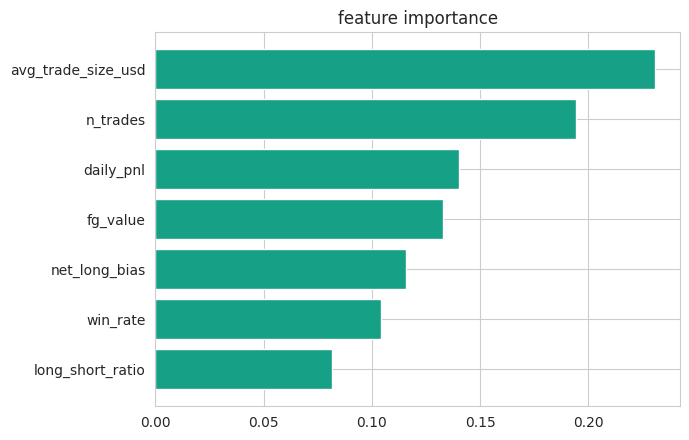

In [19]:
imp = pd.Series(clf.feature_importances_, index=features).sort_values()
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.barh(imp.index, imp.values, color='#16a085')
ax.set_title('feature importance')
plt.tight_layout()
plt.show()

Model accuracy (0.68) is actually below the "always predict profitable"
baseline (0.77) - that's expected once you balance the classes, since it's
trading raw accuracy for actually catching some of the unprofitable days
(recall on that class goes from 0 to about 48%). Today's trade size, trade
count, and pnl matter more than sentiment value itself. Not a strong enough
signal to trade on by itself, more of a starting point.

## Strategy ideas

1. Let position size scale up during Fear days, but only for accounts with
   a track record (>55% historical win rate). Large/consistent traders in
   this data do meaningfully better on Fear days, so it makes sense to lean
   into that for proven accounts rather than across the board.

2. Treat high trade frequency during Greed as a caution flag for
   inconsistent traders specifically. Their best relative results show up
   in Greed periods, which lines up with momentum-chasing in hype markets -
   a less repeatable source of returns. Worth adding a cooldown or
   confirmation step before adding to same-day positions for that segment
   when sentiment is Greed/Extreme Greed.

## Summary

Trade log (211k rows, 32 accounts) merged with the Fear/Greed index on
date, aggregated to an account x day table. Win rate only counts realized
trades (non-zero PnL) to avoid diluting it with position opens. Drawdown is
running peak minus cumulative PnL per account. No leverage/equity field
exists in the data, so trade size stands in for it wherever the brief asks
about leverage - noted above wherever used.

Main takeaways:
- Median PnL and % profitable days are a bit higher on Greed days, even
  though mean PnL looks higher on Fear (a few big wins skew it). The gap
  isn't strongly significant either way (p ≈ 0.06).
- Traders are more active, trade bigger, and lean more long during Fear -
  looks like dip-buying behavior.
- Segment matters more than sentiment alone - large/consistent traders do
  best in Fear, smaller/inconsistent traders do best in Greed.

Caveats: only 32 accounts and mostly concentrated in late 2024/early 2025,
so segment-level numbers (especially the 5-account whale group) are
directional, not precise. No leverage data available, worked around it as
noted.